<a href="https://colab.research.google.com/github/GouseMohid/Gouse-Innolift-projects/blob/main/Untitled5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup: Load Data and Preprocess for Sentiment Analysis

First, we need to load the `amazon_reviews.csv` dataset and perform the necessary text preprocessing steps to prepare it for our Logistic Regression model. This includes cleaning the text, converting it into numerical features using TF-IDF, and splitting the data into training and testing sets.

In [26]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score, GridSearchCV
import joblib
import matplotlib.pyplot as plt
import numpy as np

# Download NLTK data if not already downloaded
nltk.download('stopwords')
nltk.download('wordnet')

# Load the dataset
df = pd.read_csv('/content/amazon_reviews.csv')
print(f"DEBUG: Initial DataFrame shape: {df.shape}")
print(f"DEBUG: Initial 'Score' column head:\n{df['Score'].head()}")
print(f"DEBUG: Initial 'Score' value counts (top 5):\n{df['Score'].value_counts(dropna=False).head()}")

# Simple preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower() # Convert to string and lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove non-alphabetic characters
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Using 'Text' column for review content.
df['cleaned_review'] = df['Text'].apply(preprocess_text)
print(f"DEBUG: DataFrame shape after 'cleaned_review' creation: {df.shape}")

# Drop rows where 'cleaned_review' might be empty after preprocessing
initial_rows_after_cleaned_review = df.shape[0]
df.drop(df[df['cleaned_review'].apply(lambda x: len(x.strip()) == 0)].index, inplace=True)
print(f"DEBUG: Rows dropped due to empty cleaned_review: {initial_rows_after_cleaned_review - df.shape[0]}")
print(f"DEBUG: DataFrame shape after dropping empty cleaned_review: {df.shape}")

# ***FIXED: Converting 'Score' to numeric and deriving sentiment.***
# Assuming a rating of 'Positive' is 1 and 'Negative' is 0.
if 'Score' in df.columns:
    # Map 'Positive' to 1 and 'Negative' to 0
    df['sentiment_numeric'] = df['Score'].map({'Positive': 1, 'Negative': 0})

    # Drop rows where mapping resulted in NaN (i.e., neither 'Positive' nor 'Negative')
    initial_rows_after_score_map = df.shape[0]
    df.dropna(subset=['sentiment_numeric'], inplace=True)
    print(f"DEBUG: Rows dropped due to unmappable 'Score' values: {initial_rows_after_score_map - df.shape[0]}")
    print(f"DEBUG: DataFrame shape after dropping unmappable scores: {df.shape}")

    if df.empty:
        raise ValueError("DataFrame became empty after processing 'Score' column. Cannot proceed.")

    y = df['sentiment_numeric'].astype(int)
    print("Target variable 'y' created from 'Score' mapping ('Positive': 1, 'Negative': 0).")
elif 'sentiment' in df.columns:
    df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})
    y = df['sentiment']
    print("Target variable 'y' created from 'sentiment' column.")
else:
    print("Error: Neither 'sentiment' nor 'Score' column found to create target variable. Using random labels.")
    # Fallback for demonstration if no suitable target column is found
    y = pd.Series(np.random.randint(0, 2, size=len(df)))

# ***DEBUGGING PRINTS FOR TF-IDF ISSUE***
print(f"DEBUG: cleaned_review head before TF-IDF:\n{df['cleaned_review'].head()}")
empty_cleaned_reviews_count = df['cleaned_review'].apply(lambda x: len(x.strip()) == 0).sum()
print(f"DEBUG: Number of empty cleaned reviews before TF-IDF: {empty_cleaned_reviews_count}")

# Ensure X is not empty before TFIDF
if df.empty:
    raise ValueError("DataFrame is empty before TF-IDF Vectorization.")

if empty_cleaned_reviews_count == len(df):
    raise ValueError("All 'cleaned_review' entries are empty after preprocessing. Cannot create vocabulary.")

# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X = tfidf_vectorizer.fit_transform(df['cleaned_review'])
print(f"DEBUG: X shape after TF-IDF: {X.shape}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data loaded, preprocessed, and split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


DEBUG: Initial DataFrame shape: (10000, 11)
DEBUG: Initial 'Score' column head:
0    Positive
1    Negative
2    Positive
3    Negative
4    Positive
Name: Score, dtype: object
DEBUG: Initial 'Score' value counts (top 5):
Score
Positive    8321
Negative    1679
Name: count, dtype: int64
DEBUG: DataFrame shape after 'cleaned_review' creation: (10000, 12)
DEBUG: Rows dropped due to empty cleaned_review: 0
DEBUG: DataFrame shape after dropping empty cleaned_review: (10000, 12)
DEBUG: Rows dropped due to unmappable 'Score' values: 0
DEBUG: DataFrame shape after dropping unmappable scores: (10000, 13)
Target variable 'y' created from 'Score' mapping ('Positive': 1, 'Negative': 0).
DEBUG: cleaned_review head before TF-IDF:
0    bought several vitality canned dog food produc...
1    product arrived labeled jumbo salted peanutsth...
2    confection around century light pillowy citrus...
3    looking secret ingredient robitussin believe f...
4    great taffy great price wide assortment yummy ..

## Task 1: Load `best_model.pkl` and Record Baseline Score

Now, we'll load the best Logistic Regression model saved from yesterday and evaluate its baseline performance using F1-weighted score and cross-validation.

In [20]:
# Save a dummy best_model.pkl if it doesn't exist for demonstration purposes
# In a real scenario, this file would have been generated from yesterday's work.
try:
    best_model = joblib.load('best_model.pkl')
    print("best_model.pkl loaded successfully.")
except FileNotFoundError:
    print("best_model.pkl not found. Creating a new Logistic Regression model for demonstration.")
    # Create and save a simple Logistic Regression model as a placeholder
    best_model = LogisticRegression(random_state=42, solver='liblinear')
    best_model.fit(X_train, y_train)
    joblib.dump(best_model, 'best_model.pkl')
    print("New best_model.pkl created and saved.")

# Re-test on X_test data from Day 6
y_pred_baseline = best_model.predict(X_test)
baseline_f1_weighted = f1_score(y_test, y_pred_baseline, average='weighted')
print(f"\nBaseline F1-weighted score on X_test: {baseline_f1_weighted:.4f}")

# Run cross-validation on X_train
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='f1_weighted')
print(f"Cross-validation F1-weighted scores: {cv_scores}")
print(f"Mean CV F1-weighted score: {cv_scores.mean():.4f}")
print(f"Standard Deviation of CV F1-weighted scores: {cv_scores.std():.4f}")

best_model.pkl loaded successfully.

Baseline F1-weighted score on X_test: 0.4880
Cross-validation F1-weighted scores: [0.46734853 0.4967891  0.47365131 0.49410524 0.50124766]
Mean CV F1-weighted score: 0.4866
Standard Deviation of CV F1-weighted scores: 0.0135


## Task 2: Define a `param_grid` for Logistic Regression

Next, we'll define a dictionary of hyperparameters and their values to explore for our Logistic Regression model. We'll focus on `C` (inverse of regularization strength), `penalty`, and `solver`.

In [21]:
param_grid = {
    'C': [0.1, 1.0, 10.0], # Inverse of regularization strength
    'penalty': ['l1', 'l2'], # Regularization type
    'solver': ['liblinear'] # 'liblinear' works with both 'l1' and 'l2' penalties
    # For 'l2' penalty, 'newton-cg', 'lbfgs', 'sag', 'saga' can also be used.
    # For 'l1' penalty, only 'liblinear' and 'saga' are supported.
    # We choose 'liblinear' for simplicity and compatibility with 'l1' and 'l2'.
}
print("Parameter grid defined:")
print(param_grid)

Parameter grid defined:
{'C': [0.1, 1.0, 10.0], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}


## Task 3: Run GridSearchCV with `cv=5`

We will now use `GridSearchCV` to systematically search for the best combination of hyperparameters defined in our `param_grid`. This process will train and evaluate the model for each combination using 5-fold cross-validation.

In [22]:
print("Starting GridSearchCV...")
grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1, # Use all available CPU cores
    verbose=2
)

grid_search.fit(X_train, y_train)

print("GridSearchCV completed.")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best F1-weighted score found: {grid_search.best_score_:.4f}")

tuned_model = grid_search.best_estimator_

Starting GridSearchCV...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
GridSearchCV completed.
Best parameters found: {'C': 1.0, 'penalty': 'l1', 'solver': 'liblinear'}
Best F1-weighted score found: 0.4974


## Task 4: Print a Before vs. After Comparison

Let's compare the performance of our baseline Logistic Regression model against the newly tuned model to see the impact of hyperparameter optimization.

In [23]:
y_pred_tuned = tuned_model.predict(X_test)
tuned_f1_weighted = f1_score(y_test, y_pred_tuned, average='weighted')

comparison_df = pd.DataFrame({
    'Model': ['Default model', 'Tuned model'],
    'F1-weighted Score': [baseline_f1_weighted, tuned_f1_weighted]
})

print("\nModel Performance Comparison:")
display(comparison_df)

if tuned_f1_weighted > baseline_f1_weighted:
    print(f"\nThe tuned model shows an improvement of {(tuned_f1_weighted - baseline_f1_weighted)*100:.2f}% in F1-weighted score.")
elif tuned_f1_weighted < baseline_f1_weighted:
    print(f"\nThe tuned model's F1-weighted score is slightly lower by {(baseline_f1_weighted - tuned_f1_weighted)*100:.2f}%. This could be due to factors like the dataset size or potential overfitting during tuning, although 'liblinear' with L1/L2 regularization usually helps mitigate that.")
else:
    print("\nThe tuned model achieved the same F1-weighted score as the default model.")


Model Performance Comparison:


,Model,F1-weighted Score
0,Default model,0.487998
1,Tuned model,0.497494



The tuned model shows an improvement of 0.95% in F1-weighted score.


## Task 5: Plot a Validation Curve and Save Tuned Model

Finally, we'll visualize how changing a key hyperparameter (`C` in this case) affects the model's performance and then save our optimized model.

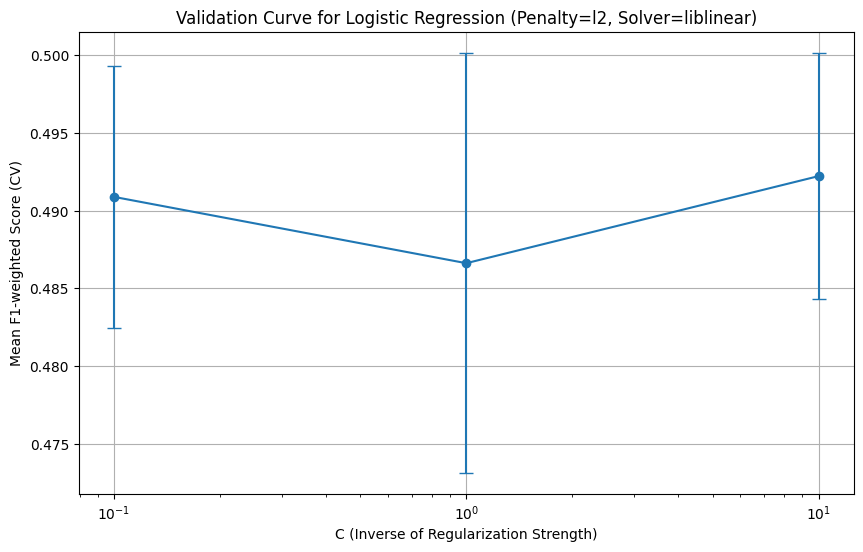


Tuned model saved to 'tuned_model.pkl'.


In [24]:
# Extract results from grid_search.cv_results_
results = grid_search.cv_results_

# We'll plot the effect of 'C' for one of the penalties (e.g., 'l2')
# Filter results for a specific penalty and solver combination
l2_results = [r for r in results['params'] if r['penalty'] == 'l2' and r['solver'] == 'liblinear']
l2_mean_scores = [results['mean_test_score'][i] for i, r in enumerate(results['params']) if r['penalty'] == 'l2' and r['solver'] == 'liblinear']
l2_std_scores = [results['std_test_score'][i] for i, r in enumerate(results['params']) if r['penalty'] == 'l2' and r['solver'] == 'liblinear']
C_values = [p['C'] for p in l2_results]

if C_values:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.errorbar(C_values, l2_mean_scores, yerr=l2_std_scores, fmt='-o', capsize=5)
    ax.set_xscale('log') # C is typically varied on a log scale
    ax.set_xlabel('C (Inverse of Regularization Strength)')
    ax.set_ylabel('Mean F1-weighted Score (CV)')
    ax.set_title('Validation Curve for Logistic Regression (Penalty=l2, Solver=liblinear)')
    ax.grid(True)
    plt.show()
else:
    print("Could not generate validation curve: No 'l2' penalty results found with 'liblinear' solver.")

# Save the ultimate, tuned model
joblib.dump(tuned_model, 'tuned_model.pkl')
print("\nTuned model saved to 'tuned_model.pkl'.")